In [1]:
!pip install prophet --quiet
!pip install pandas numpy matplotlib seaborn plotly scipy --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from scipy.signal import find_peaks
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',50)

In [7]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')    #date col to datetime format , coerce for coversion of invalid values to NaT

print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min()}  to  {df['date'].max()}")
print(f"Countries: {df['location'].nunique()}")            #counting unique countries
print(f"\nFirst 5 columns: {list(df.columns[:5])}")
print(f"Last 5 columns: {list(df.columns[-5:])}")

df.head(5)

Shape: (429435, 67)
Date range: 2020-01-01 00:00:00  to  2024-08-14 00:00:00
Countries: 255

First 5 columns: ['iso_code', 'continent', 'location', 'date', 'total_cases']
Last 5 columns: ['population', 'excess_mortality_cumulative_absolute', 'excess_mortality_cumulative', 'excess_mortality', 'excess_mortality_cumulative_per_million']


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths_per_million,new_deaths_per_million,new_deaths_smoothed_per_million,reproduction_rate,icu_patients,icu_patients_per_million,hosp_patients,hosp_patients_per_million,weekly_icu_admissions,weekly_icu_admissions_per_million,weekly_hosp_admissions,weekly_hosp_admissions_per_million,...,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,new_vaccinations_smoothed_per_million,new_people_vaccinated_smoothed,new_people_vaccinated_smoothed_per_hundred,stringency_index,population_density,median_age,aged_65_older,aged_70_older,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,54.42,18.6,2.58,1.34,1803.99,NaN,597.03,9.59,NaN,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,54.42,18.6,2.58,1.34,1803.99,NaN,597.03,9.59,NaN,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,54.42,18.6,2.58,1.34,1803.99,NaN,597.03,9.59,NaN,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,54.42,18.6,2.58,1.34,1803.99,NaN,597.03,9.59,NaN,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,54.42,18.6,2.58,1.34,1803.99,NaN,597.03,9.59,NaN,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [49]:

gdp_raw = pd.read_csv('gdp_worldbank.csv.csv', skiprows=4)       #garbage text in starting rows

print("Raw columns:", list(gdp_raw.columns[:8]))
print("Shape:", gdp_raw.shape)
gdp_raw.head(3)

Raw columns: ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963']
Shape: (266, 71)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,...,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.961844e+09,2.044112e+09,2.254831e+09,2.360017e+09,2.469783e+09,2.677641e+09,2.843025e+09,2.553793e+09,2.453597e+09,2.637859e+09,2.615208e+09,2.727849e+09,2.790850e+09,2.962907e+09,2.983637e+09,3.092428e+09,3.276188e+09,3.346623e+09,2.471419e+09,2.880903e+09,3.324034e+09,3.834730e+09,4.265651e+09,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2.420569e+10,2.495889e+10,2.707323e+10,3.176914e+10,3.027955e+10,3.380618e+10,3.692725e+10,3.844416e+10,4.174200e+10,4.704852e+10,4.759391e+10,5.218869e+10,5.672606e+10,7.308360e+10,8.953598e+10,9.529575e+10,9.600642e+10,1.092082e+11,1.240834e+11,1.421000e+11,1.784723e+11,...,2.697460e+11,3.581161e+11,4.459748e+11,5.215620e+11,5.875005e+11,6.749999e+11,7.267704e+11,7.269216e+11,8.638221e+11,9.598225e+11,9.692657e+11,9.813089e+11,9.988362e+11,9.100020e+11,8.318681e+11,9.780765e+11,1.020956e+12,1.018715e+12,9.386076e+11,1.114145e+12,1.228968e+12,1.179359e+12,1.242694e+12,NaN,NaN
2,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.825701e+09,4.520947e+09,5.224897e+09,6.203257e+09,6.971758e+09,9.747886e+09,1.010930e+10,1.241615e+10,1.585667e+10,1.780510e+10,1.990733e+10,2.014642e+10,2.049713e+10,1.913422e+10,1.811657e+10,1.875346e+10,1.805322e+10,1.879944e+10,1.995593e+10,1.426000e+10,1.449724e+10,1.715223e+10,NaN,NaN,NaN


In [10]:
gdp = gdp_raw[['Country Name', '2019']].copy()
gdp.columns = ['location', 'gdp_2019']             #country name to location col name renamed for furture
gdp = gdp.dropna(subset=['gdp_2019'])              #removing rows where GDP missing
gdp['gdp_2019'] = pd.to_numeric(gdp['gdp_2019'], errors='coerce')        #gdp to float and invalid to NaN
gdp = gdp.dropna()

print(f"GDP records loaded: {len(gdp)}")
print(gdp.head(8))

GDP records loaded: 259
                      location      gdp_2019
0                        Aruba  3.346623e+09
1  Africa Eastern and Southern  1.018715e+12
2                  Afghanistan  1.879944e+10
3   Africa Western and Central  1.026996e+12
4                       Angola  8.073443e+10
5                      Albania  1.558511e+10
6                      Andorra  3.155150e+09
7                   Arab World  2.965286e+12


In [13]:
print("OWID COVID DATASET")
print(f"\nRows: {len(df):,}")         #tot rows (adding commas)
print(f"Columns: {df.shape[1]}")    #no. of column (features)
print(f"Date range: {df['date'].min()} → {df['date'].max()}")   #time converage
print(f"Locations: {df['location'].nunique()}")

#data completeness check
print("\nKey columns available:")
key_cols = ['new_cases', 'new_deaths', 'total_cases', 'total_deaths',    # important features!
            'total_vaccinations', 'people_vaccinated_per_hundred',
            'gdp_per_capita', 'human_development_index',
            'median_age', 'hospital_beds_per_thousand', 'population']

#measuring data completness
for col in key_cols:  #check for each feature
    pct_filled = df[col].notna().mean() * 100                #converting col to T/F and T=1,F=0 to check how much percent of the data in that col is usable
    print(f"  {col:<40} {pct_filled:.0f}% filled")

print("\nGDP DATASET")
print(f"\nRows: {len(gdp):,}")
print(f"Sample countries: {list(gdp['location'].head(5))}")    #to check if the values inside 'location' match b/w datasets?

OWID COVID DATASET

Rows: 429,435
Columns: 67
Date range: 2020-01-01 00:00:00 → 2024-08-14 00:00:00
Locations: 255

Key columns available:
  new_cases                                96% filled
  new_deaths                               96% filled
  total_cases                              96% filled
  total_deaths                             96% filled
  total_vaccinations                       20% filled
  people_vaccinated_per_hundred            19% filled
  gdp_per_capita                           76% filled
  human_development_index                  74% filled
  median_age                               78% filled
  hospital_beds_per_thousand               68% filled
  population                               100% filled

GDP DATASET

Rows: 259
Sample countries: ['Aruba', 'Africa Eastern and Southern', 'Afghanistan', 'Africa Western and Central', 'Angola']


In [18]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

#keeping only real countries using ISO codes
df = df[df['continent'].notna()].copy()

print(f"Countries remaining: {df['location'].nunique()}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Any null dates: {df['date'].isna().sum()}")

Countries remaining: 237
Date range: 2020-01-01 to 2024-08-14
Any null dates: 0


In [22]:
df = df.sort_values(['location', 'date']).reset_index(drop=True)  #sorting by location and reassign row no. from 0 to n-1

In [23]:
cumulative_cols = ['total_cases', 'total_deaths',  #running totals, never decrease over time
                  'total_vaccinations',
                  'people_vaccinated_per_hundred']

df[cumulative_cols] = (df.groupby('location')[cumulative_cols] #groups data by location, applying forward fill
                         .ffill())

daily_cols = ['new_cases', 'new_deaths']  #per-day values
df[daily_cols] = df[daily_cols].fillna(0)  #replacing missing daily values with 0

df[daily_cols] = df[daily_cols].clip(lower=0)  #removing negative values

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
iso_code                                        0
continent                                       0
location                                        0
date                                            0
total_cases                                  3807
                                            ...  
population                                      0
excess_mortality_cumulative_absolute       381948
excess_mortality_cumulative                381948
excess_mortality                           381948
excess_mortality_cumulative_per_million    381948
Length: 67, dtype: int64


In [27]:
df['new_cases_7da'] = (df.groupby('location')['new_cases']    #7 day moving avg for cases
                          .transform(lambda x:
                              x.rolling(7, min_periods=1).mean().round(2)))

df['new_deaths_7da'] = (df.groupby('location')['new_deaths']  #7 day moving avg for death cases
                         .transform(lambda x:
                              x.rolling(7, min_periods=1).mean().round(2)))

print("Sample — raw vs smoothed:")
sample = df[df['location'] == 'India'][
    ['date', 'new_cases', 'new_cases_7da']].tail(10)
print(sample.to_string(index=False))

Sample — raw vs smoothed:
      date  new_cases  new_cases_7da
2024-08-03        0.0          34.71
2024-08-04      313.0          44.71
2024-08-05        0.0          44.71
2024-08-06        0.0          44.71
2024-08-07        0.0          44.71
2024-08-08        0.0          44.71
2024-08-09        0.0          44.71
2024-08-10        0.0          44.71
2024-08-11        0.0           0.00
2024-08-12        0.0           0.00


In [37]:
import io

gdp_raw = pd.read_csv('gdp_worldbank.csv.csv', skiprows=4)

print("Columns found:", list(gdp_raw.columns[:8]))
print("Sample rows:")
print(gdp_raw.head(3).to_string())

Columns found: ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963']
Sample rows:
                  Country Name Country Code     Indicator Name  Indicator Code          1960          1961          1962          1963          1964          1965          1966          1967          1968          1969          1970          1971          1972          1973          1974          1975          1976          1977          1978          1979          1980          1981          1982          1983          1984          1985          1986          1987          1988          1989          1990          1991          1992          1993          1994          1995          1996          1997          1998          1999          2000          2001          2002          2003          2004          2005          2006          2007          2008          2009          2010          2011          2012          2013          2014          2015         

In [47]:
#droping any gdp_2019 variants if they exist
gdp_cols_to_drop = [c for c in df.columns if 'gdp_2019' in c]
if gdp_cols_to_drop:
    df = df.drop(columns=gdp_cols_to_drop)

#merge
df = df.merge(gdp, on='location', how='left')

#confirm
print("Success:", 'gdp_2019' in df.columns)
print(f"GDP matched for {df['gdp_2019'].notna().sum():,} rows")
print(f"Countries without GDP data: {df[df['gdp_2019'].isna()]['location'].nunique()}")
print(f"df shape: {df.shape}")

Success: True
GDP matched for 301,777 rows
Countries without GDP data: 57
df shape: (395311, 70)


In [48]:
df.to_csv('covid_clean.csv', index=False)
print(f"Saved: covid_clean.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Saved: covid_clean.csv
Shape: (395311, 70)
Columns: ['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients', 'icu_patients_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations', 'new_vaccinations_smoothed', 'total_vaccinations_per_hundred', 'people_vaccinated_per_hund

In [54]:
#Exploration data analysis (EDA)
#which of these countries had the highest total COVID cases?
COUNTRIES = ['India', 'United States', 'Brazil',
             'United Kingdom', 'Germany',
             'South Africa', 'Japan', 'Australia']

df_focus = df[df['location'].isin(COUNTRIES)].copy()

print("Focus countries — max total cases:")
print(df_focus.groupby('location')['total_cases']
              .max()
              .sort_values(ascending=False)
              .to_string())

Focus countries — max total cases:
location
United States     103436829.0
India              45041748.0
Germany            38437756.0
Brazil             37511921.0
Japan              33803572.0
United Kingdom     24974629.0
Australia          11861161.0
South Africa        4072765.0


In [55]:
summary = df_focus.groupby('location').agg(
    total_cases        = ('total_cases',  'max'),
    total_deaths       = ('total_deaths', 'max'),
    max_vacc_pct       = ('people_vaccinated_per_hundred', 'max'),
    population         = ('population',  'first'),
    gdp_per_capita     = ('gdp_per_capita', 'first'),
    hdi                = ('human_development_index', 'first')
).reset_index()
#covert daily rows to one summary row per country

summary['cfr'] = (summary['total_deaths'] /
                  summary['total_cases'] * 100).round(2)   #case fatality rate

summary['cases_per_million'] = (summary['total_cases'] /
                                 summary['population'] * 1e6).round(0)  #normalisation

print(summary[['location','total_cases','cfr',
               'max_vacc_pct','cases_per_million']]
      .sort_values('cfr', ascending=False)
      .to_string(index=False))

      location  total_cases  cfr  max_vacc_pct  cases_per_million
  South Africa    4072765.0 2.52         40.42            68000.0
        Brazil   37511921.0 1.87         88.08           174220.0
         India   45041748.0 1.18         72.50            31783.0
 United States  103436829.0 1.15         81.39           305764.0
United Kingdom   24974629.0 0.93         79.71           369946.0
       Germany   38437756.0 0.46         77.82           461051.0
         Japan   33803572.0 0.22         84.47           272716.0
     Australia   11861161.0 0.21         84.93           453107.0


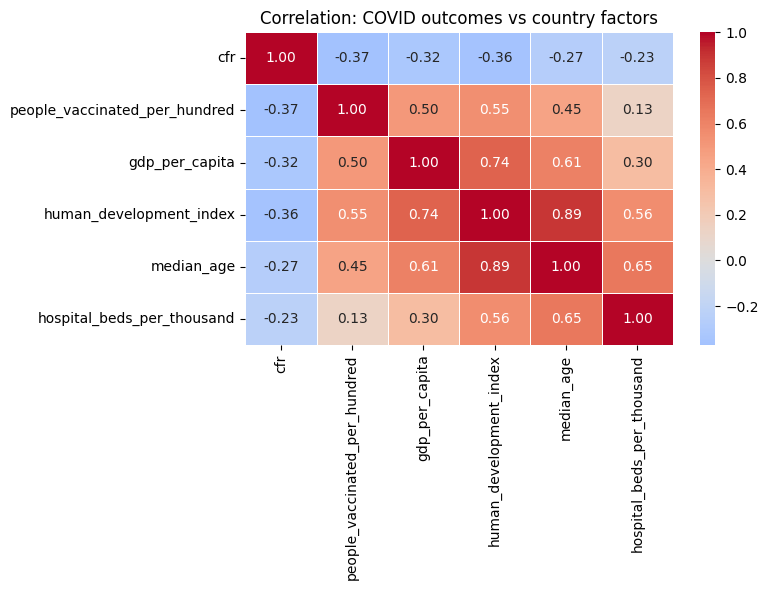

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

latest = (df.sort_values('date')
            .groupby('location')
            .last()
            .reset_index())

latest['cfr'] = (latest['total_deaths'] /
                 latest['total_cases'] * 100)

corr_cols = ['cfr', 'people_vaccinated_per_hundred',   #variables for correlation
             'gdp_per_capita', 'human_development_index',
             'median_age', 'hospital_beds_per_thousand']

corr = latest[corr_cols].dropna().corr().round(2)  #computing correlation matrix

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm',
            center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation: COVID outcomes vs country factors')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [57]:
df_focus.to_csv('covid_clean_focus.csv', index=False)
summary.to_csv('country_summary.csv', index=False)
print("Saved: covid_clean_focus.csv and country_summary.csv")

Saved: covid_clean_focus.csv and country_summary.csv


In [60]:
from scipy.signal import find_peaks
import numpy as np

def detect_waves(country_df, country_name,
                 prominence_pct=0.15, min_distance_days=30):

    #smoothed daily cases (7-day avg)
    series = country_df['new_cases_7da'].fillna(0).values
    max_val = series.max()

    #no data = no waves
    if max_val == 0:
        return pd.DataFrame()

    #detect peaks (waves)
    peaks, props = find_peaks(
        series,
        prominence = max_val * prominence_pct,   #ignore small bumps
        distance   = min_distance_days           #enforce gap between waves
    )

    #map peak indices = actual dates and values
    peak_dates  = country_df['date'].iloc[peaks].values
    peak_values = series[peaks]

    return pd.DataFrame({
        'country':        country_name,
        'wave':           range(1, len(peaks) + 1),
        'peak_date':      peak_dates,
        'peak_cases_7da': peak_values.round(0)
    })

In [62]:
all_waves = []  #running for all focused countries
for country in COUNTRIES:
    cdf = df_focus[df_focus['location'] == country].copy()
    waves = detect_waves(cdf, country)
    all_waves.append(waves)
    print(f"{country}: {len(waves)} wave(s) detected")

waves_df = pd.concat(all_waves, ignore_index=True)
print("\n", waves_df.to_string(index=False))

India: 3 wave(s) detected
United States: 2 wave(s) detected
Brazil: 5 wave(s) detected
United Kingdom: 3 wave(s) detected
Germany: 3 wave(s) detected
South Africa: 5 wave(s) detected
Japan: 3 wave(s) detected
Australia: 3 wave(s) detected

        country  wave  peak_date  peak_cases_7da
         India     1 2020-09-23         92323.0
         India     2 2021-05-12        391280.0
         India     3 2022-01-26        302157.0
 United States     1 2021-01-13        238164.0
 United States     2 2022-01-19        807276.0
        Brazil     1 2020-08-05         45588.0
        Brazil     2 2021-03-31         76146.0
        Brazil     3 2022-02-02        183289.0
        Brazil     4 2022-07-20         59896.0
        Brazil     5 2022-12-21         48259.0
United Kingdom     1 2021-01-13         60382.0
United Kingdom     2 2022-01-12        188619.0
United Kingdom     3 2022-03-30         86625.0
       Germany     1 2022-03-30        226984.0
       Germany     2 2022-07-20        

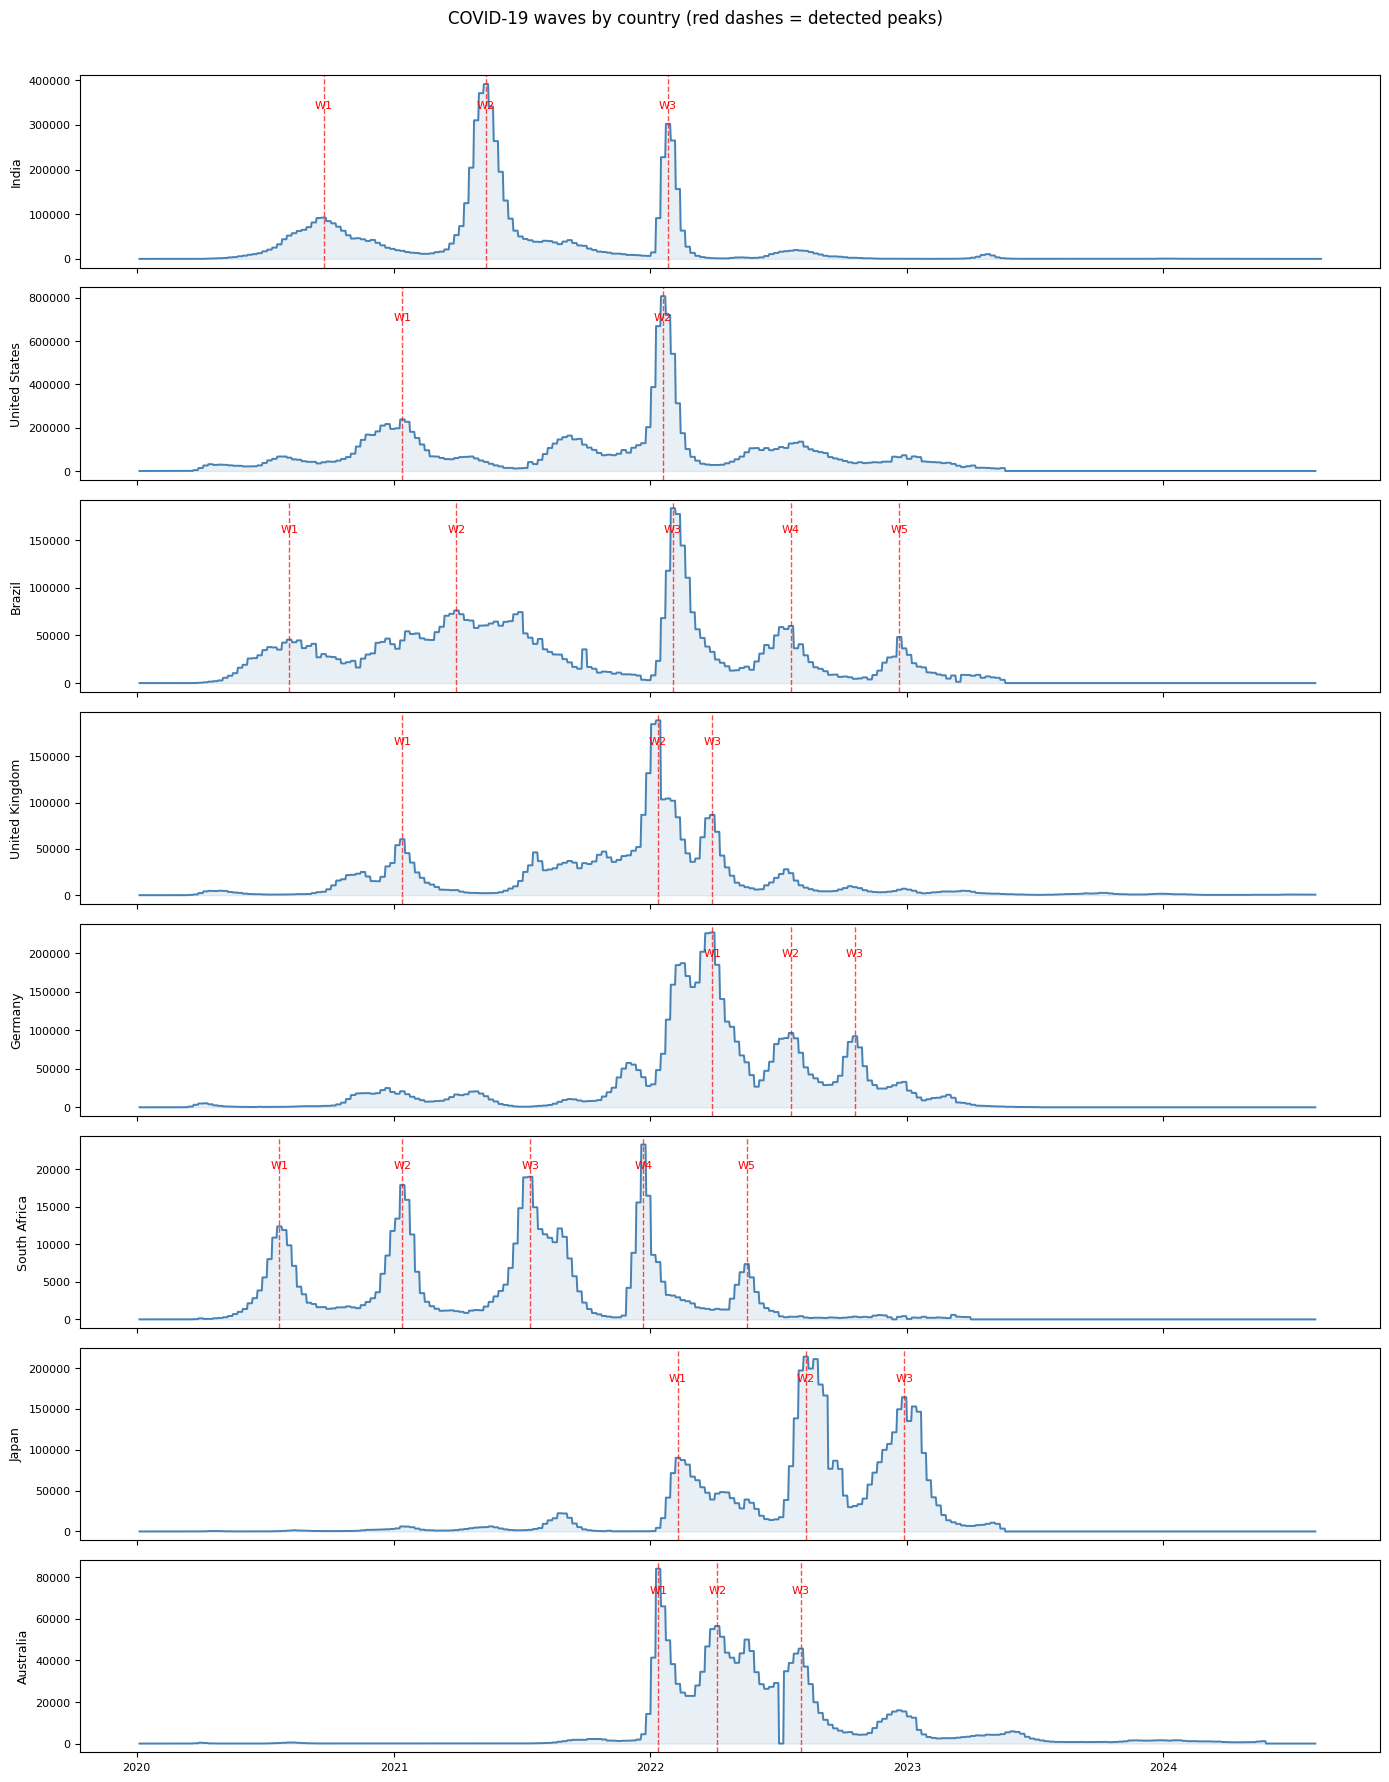

In [64]:
n = len(COUNTRIES)

# 1 vertical subplot per country, all sharing the same date axis
fig, axes = plt.subplots(n, 1, figsize=(14, n * 2.2), sharex=True)

for ax, country in zip(axes, COUNTRIES):
    #filtering data for the current country
    cdf = df_focus[df_focus['location'] == country]

    #plot 7 day smoothed cases
    ax.plot(cdf['date'], cdf['new_cases_7da'],
            linewidth=1.4, color='steelblue')
    ax.fill_between(cdf['date'], cdf['new_cases_7da'],
                    alpha=0.12, color='steelblue')

    #get detected wave peaks for this country
    cw = waves_df[waves_df['country'] == country]

    for _, row in cw.iterrows():
        #draw vertical dashed line at each wave peak
        ax.axvline(pd.Timestamp(row['peak_date']),
                   color='red', linestyle='--',
                   alpha=0.7, linewidth=1)

        #label each wave (W1, W2, etc.) near the top of the plot
        ax.text(pd.Timestamp(row['peak_date']),
                ax.get_ylim()[1] * 0.82,
                f"W{int(row['wave'])}",
                fontsize=8, color='red', ha='center')

    #use country name as y axis label for each subplot
    ax.set_ylabel(country, fontsize=9)

    #keep axis text small so multiple plots fit cleanly
    ax.tick_params(labelsize=8)

    #remove x label here (shared axis handled below)
    ax.set_xlabel('')

plt.suptitle('COVID-19 waves by country (red dashes = detected peaks)',
             fontsize=12, y=1.01)
plt.tight_layout()

plt.savefig('wave_detection.png', dpi=150, bbox_inches='tight')

plt.show()

In [65]:
waves_df.to_csv('wave_dates.csv', index=False)
print("Saved: wave_dates.csv")
print(waves_df.to_string(index=False))

Saved: wave_dates.csv
       country  wave  peak_date  peak_cases_7da
         India     1 2020-09-23         92323.0
         India     2 2021-05-12        391280.0
         India     3 2022-01-26        302157.0
 United States     1 2021-01-13        238164.0
 United States     2 2022-01-19        807276.0
        Brazil     1 2020-08-05         45588.0
        Brazil     2 2021-03-31         76146.0
        Brazil     3 2022-02-02        183289.0
        Brazil     4 2022-07-20         59896.0
        Brazil     5 2022-12-21         48259.0
United Kingdom     1 2021-01-13         60382.0
United Kingdom     2 2022-01-12        188619.0
United Kingdom     3 2022-03-30         86625.0
       Germany     1 2022-03-30        226984.0
       Germany     2 2022-07-20         96447.0
       Germany     3 2022-10-19         92141.0
  South Africa     1 2020-07-22         12385.0
  South Africa     2 2021-01-13         17898.0
  South Africa     3 2021-07-14         18998.0
  South Africa    

In [66]:
#forecasting with prophet
!pip install prophet --quiet
from prophet import Prophet
print("Prophet ready")

Prophet ready


In [67]:
def forecast_country(df_focus, country, periods=30):
    cdf = (df_focus[df_focus['location'] == country]
           [['date', 'new_cases_7da']]
           .copy()
           .rename(columns={'date': 'ds',
                            'new_cases_7da': 'y'})
           .dropna())

    cdf['y'] = cdf['y'].clip(lower=0)

    model = Prophet(
        yearly_seasonality      = True,
        weekly_seasonality      = True,
        daily_seasonality       = False,
        changepoint_prior_scale = 0.3,
        interval_width          = 0.95
    )
    model.fit(cdf)

    future   = model.make_future_dataframe(periods=periods)
    forecast = model.predict(future)

    return model, forecast, cdf

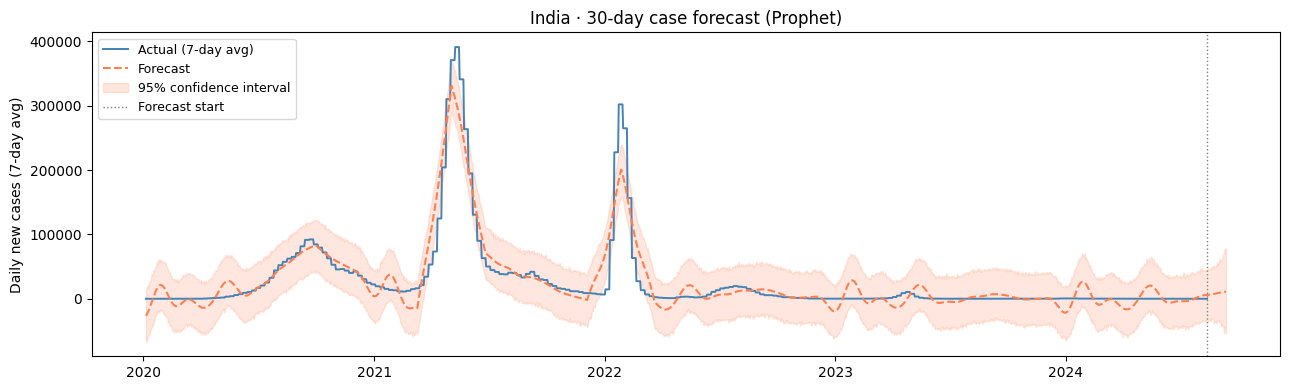


30-day forecast (last 10 rows):
        ds         yhat    yhat_lower   yhat_upper
2024-09-02  9922.420733 -35833.926454 57527.157757
2024-09-03 10156.245284 -42512.870064 57740.706353
2024-09-04 10346.865032 -42460.863051 60962.320562
2024-09-05 10492.099885 -40672.303590 63345.994067
2024-09-06 10644.527905 -38845.577480 67769.332697
2024-09-07 10774.311253 -45306.393327 69199.459607
2024-09-08 10959.248386 -54219.037900 71623.022432
2024-09-09 11002.597006 -43574.501919 78060.807036
2024-09-10 11077.746948 -45266.231313 75798.575843
2024-09-11 11103.480053 -52824.690181 78155.321890


In [69]:
#forecasting model
country = 'India'
model, forecast, actual = forecast_country(df_focus, country, periods=30)

fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(actual['ds'], actual['y'],
        color='steelblue', linewidth=1.4, label='Actual (7-day avg)')

#plot forecast
ax.plot(forecast['ds'], forecast['yhat'],
        color='coral', linewidth=1.5,
        linestyle='--', label='Forecast')

#confidence interval(uncertainty)
ax.fill_between(forecast['ds'],
                forecast['yhat_lower'],
                forecast['yhat_upper'],
                alpha=0.18, color='coral',
                label='95% confidence interval')

cutoff = actual['ds'].max()
ax.axvline(cutoff, color='gray',
           linestyle=':', linewidth=1,
           label='Forecast start')

ax.set_title(f'{country} · 30-day case forecast (Prophet)',
             fontsize=12)
ax.set_ylabel('Daily new cases (7-day avg)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'forecast_{country}.png', dpi=150)
plt.show()

print("\n30-day forecast (last 10 rows):")
future_rows = forecast[forecast['ds'] > cutoff]
print(future_rows[['ds','yhat','yhat_lower',
                    'yhat_upper']].tail(10).to_string(index=False))

In [70]:
all_forecasts = []

for country in COUNTRIES:
    try:
        _, forecast, _ = forecast_country(
            df_focus, country, periods=30)
        forecast['location'] = country
        all_forecasts.append(
            forecast[['location','ds','yhat',
                       'yhat_lower','yhat_upper']])
        print(f"  {country}: done")
    except Exception as e:
        print(f"  {country}: FAILED — {e}")

forecasts_df = pd.concat(all_forecasts, ignore_index=True)
forecasts_df.to_csv('covid_forecasts.csv', index=False)
print(f"\nSaved: covid_forecasts.csv ({len(forecasts_df):,} rows)")

  India: done
  United States: done
  Brazil: done
  United Kingdom: done
  Germany: done
  South Africa: done
  Japan: done
  Australia: done

Saved: covid_forecasts.csv (13,640 rows)


In [79]:
#statistical analysis
#prep analysis dataframe
from scipy import stats

latest = (df.sort_values('date')
            .groupby('location')
            .last()
            .reset_index())

latest['cfr'] = (latest['total_deaths'] /
                 latest['total_cases'] * 100)

analysis_df = latest[['location',
                       'people_vaccinated_per_hundred',
                       'cfr', 'gdp_per_capita',
                       'human_development_index',
                       'median_age',
                       'hospital_beds_per_thousand']].dropna()

print(f"Countries with complete data: {len(analysis_df)}")   #counting usable countries

Countries with complete data: 158


In [80]:
#linear regression
#does vaccination rate relate to CFR (Death rate)?
x = analysis_df['people_vaccinated_per_hundred']
y = analysis_df['cfr']

#run regression y=(mx)+b ; slope = m , intercept = b
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print("Regression: vaccination rate → CFR")
print(f"  Slope:       {slope:.4f}")
print(f"  Intercept:   {intercept:.4f}")
print(f"  R²:          {r_value**2:.4f}")
print(f"  P-value:     {p_value:.6f}")
print(f"  Std error:   {std_err:.4f}")
print(f"  Significant: {'YES (p < 0.05)' if p_value < 0.05 else 'NO'}")

Regression: vaccination rate → CFR
  Slope:       -0.0273
  Intercept:   3.1423
  R²:          0.1382
  P-value:     0.000002
  Std error:   0.0055
  Significant: YES (p < 0.05)


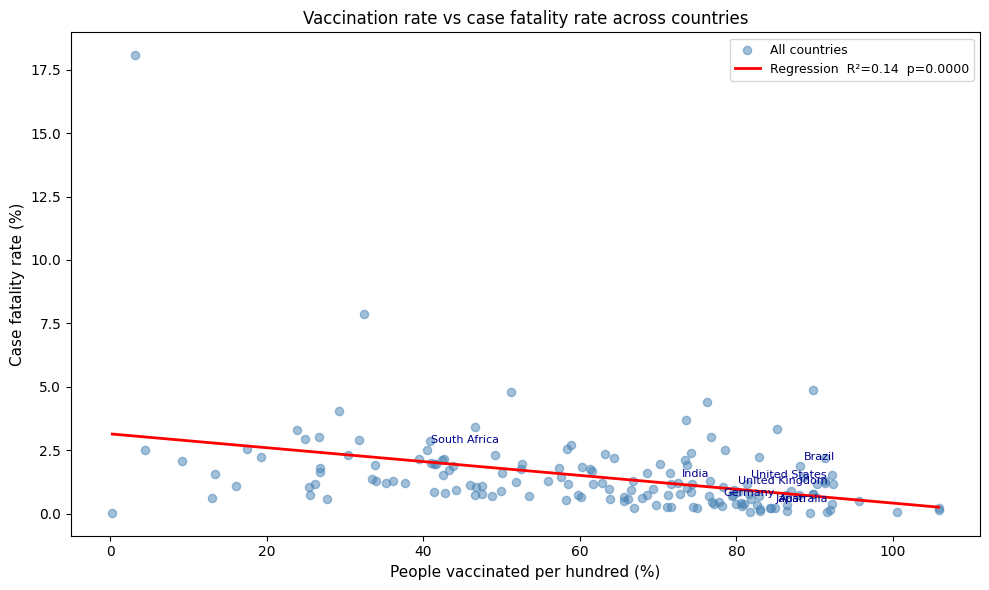

In [81]:
#visualising regression result
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(x, y, alpha=0.5, color='steelblue',
           s=35, label='All countries')

x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='red', linewidth=2,
        label=f'Regression  R²={r_value**2:.2f}  p={p_value:.4f}')

focus_data = analysis_df[
    analysis_df['location'].isin(COUNTRIES)]
for _, row in focus_data.iterrows():
    ax.annotate(
        row['location'],
        xy=(row['people_vaccinated_per_hundred'], row['cfr']),
        fontsize=8, ha='left', va='bottom', color='darkblue',
        xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('People vaccinated per hundred (%)', fontsize=11)
ax.set_ylabel('Case fatality rate (%)', fontsize=11)
ax.set_title('Vaccination rate vs case fatality rate across countries',
             fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('regression_vacc_cfr.png', dpi=150)
plt.show()

In [82]:
#pearson correlation table
metrics = ['cfr',
           'people_vaccinated_per_hundred',  #features comparing against each other
           'gdp_per_capita',
           'human_development_index',
           'median_age',
           'hospital_beds_per_thousand']

print(f"{'Pair':<52} {'r':>7} {'p-value':>10} {'sig':>8}")
print("-" * 82)

for i, m1 in enumerate(metrics):  #avoiding duplicates like cfr vs gdp and gdp vs cfr , also a variable with itself
    for m2 in metrics[i+1:]:
        clean = analysis_df[[m1, m2]].dropna()  #cleaning data for each pair
        if len(clean) < 10:  #skipping small samples
            continue
        r, p = stats.pearsonr(clean[m1], clean[m2])  # r= correlation coefficient(-1 to +1), p=statistical significance
        sig = ("***" if p < 0.001  #assigning significance level , *** - very strong evidence
               else "**" if p < 0.01  #stong
               else "*"  if p < 0.05  #moderate
               else "ns")             #not significant
        pair = f"{m1} vs {m2}"
        print(f"{pair:<52} {r:>7.3f} {p:>10.4f} {sig:>8}")

Pair                                                       r    p-value      sig
----------------------------------------------------------------------------------
cfr vs people_vaccinated_per_hundred                  -0.372     0.0000      ***
cfr vs gdp_per_capita                                 -0.321     0.0000      ***
cfr vs human_development_index                        -0.361     0.0000      ***
cfr vs median_age                                     -0.270     0.0006      ***
cfr vs hospital_beds_per_thousand                     -0.228     0.0039       **
people_vaccinated_per_hundred vs gdp_per_capita        0.503     0.0000      ***
people_vaccinated_per_hundred vs human_development_index   0.553     0.0000      ***
people_vaccinated_per_hundred vs median_age            0.449     0.0000      ***
people_vaccinated_per_hundred vs hospital_beds_per_thousand   0.127     0.1121       ns
gdp_per_capita vs human_development_index              0.744     0.0000      ***
gdp_per_capita 

In [83]:
#welch t-test - high vs low vaccination groups
#High vaccination vs Low vaccination - do they have different CFRs?

threshold = 50  #splitting countries into 2 groups
high = analysis_df[
    analysis_df['people_vaccinated_per_hundred'] >= threshold]['cfr']
low  = analysis_df[
    analysis_df['people_vaccinated_per_hundred'] < threshold]['cfr']

#running weltch's test
#compares means of two groups- doesn't assume equal variance , robust in real data
t_stat, p_val = stats.ttest_ind(high, low, equal_var=False)

print("Welch t-test: high vs low vaccination countries")
print(f"  High vacc (≥{threshold}%): mean CFR = {high.mean():.2f}%"
      f"  n = {len(high)}")
print(f"  Low  vacc (<{threshold}%): mean CFR = {low.mean():.2f}%"
      f"  n = {len(low)}")
print(f"  t-statistic: {t_stat:.3f}")   #measures how far apart the group means are , larger magnitude = bigger diff
print(f"  p-value:     {p_val:.4f}")    #prob diff is due to chance , <0.05 - significant diff , >=0.05 - no reliable diff
print(f"  Result: {'Significant difference found' if p_val < 0.05 else 'No significant difference'}")

Welch t-test: high vs low vaccination countries
  High vacc (≥50%): mean CFR = 1.12%  n = 107
  Low  vacc (<50%): mean CFR = 2.15%  n = 51
  t-statistic: -2.753
  p-value:     0.0079
  Result: Significant difference found


In [76]:
import os

outputs = {
    'covid_clean.csv':          'Full cleaned dataset',
    'covid_clean_focus.csv':    '8-country subset',
    'country_summary.csv':      'Per-country metrics table',
    'wave_dates.csv':           'Detected wave peak dates',
    'covid_forecasts.csv':      '30-day Prophet forecasts',
    'correlation_heatmap.png':  'Correlation heatmap image',
    'wave_detection.png':       'Wave detection chart image',
    'regression_vacc_cfr.png':  'Regression scatter image',
}

print("Output file check:")
for fname, desc in outputs.items():
    exists = os.path.exists(fname)
    size   = (f"{os.path.getsize(fname)/1024:.0f} KB"
              if exists else "MISSING")
    status = "OK" if exists else "MISSING -- rerun that step"
    print(f"  {status:<8} {fname:<35} {size:<10}  {desc}")

Output file check:
  OK       covid_clean.csv                     105237 KB   Full cleaned dataset
  OK       covid_clean_focus.csv               4557 KB     8-country subset
  OK       country_summary.csv                 1 KB        Per-country metrics table
  OK       wave_dates.csv                      1 KB        Detected wave peak dates
  OK       covid_forecasts.csv                 1026 KB     30-day Prophet forecasts
  OK       correlation_heatmap.png             112 KB      Correlation heatmap image
  OK       wave_detection.png                  282 KB      Wave detection chart image
  OK       regression_vacc_cfr.png             95 KB       Regression scatter image


In [77]:
print("=" * 55)
print("KEY FINDINGS — Person 1 analysis")
print("=" * 55)

print(f"\nDataset")
print(f"  Countries analysed : {df['location'].nunique()}")
print(f"  Date range         : {df['date'].min().date()}"
      f" to {df['date'].max().date()}")

g = df.groupby('location')
total_cases  = g['total_cases'].max().sum()
total_deaths = g['total_deaths'].max().sum()
print(f"\nGlobal totals")
print(f"  Total cases  : {total_cases:,.0f}")
print(f"  Total deaths : {total_deaths:,.0f}")
print(f"  Global CFR   : {total_deaths/total_cases*100:.2f}%")

print(f"\nRegression (vaccination rate → CFR)")
print(f"  R²       : {r_value**2:.3f}")
print(f"  p-value  : {p_value:.6f}")
print(f"  Slope    : {slope:.4f} "
      "(CFR change per 1% increase in vaccination)")

print(f"\nWelch t-test (high vs low vaccination)")
print(f"  p-value  : {p_val:.4f}")
print(f"  Result   : "
      f"{'Significant' if p_val < 0.05 else 'Not significant'}")

print(f"\nWave detection")
print(f"  Total waves found  : {len(waves_df)}")
print(f"  Across countries   : {waves_df['country'].nunique()}")
most_waves = waves_df.groupby('country')['wave'].max().idxmax()
print(f"  Most waves         : {most_waves}"
      f" ({waves_df.groupby('country')['wave'].max().max()} waves)")

KEY FINDINGS — Person 1 analysis

Dataset
  Countries analysed : 237
  Date range         : 2020-01-01 to 2024-08-14

Global totals
  Total cases  : 775,625,912
  Total deaths : 7,055,673
  Global CFR   : 0.91%

Regression (vaccination rate → CFR)
  R²       : 0.138
  p-value  : 0.000002
  Slope    : -0.0273 (CFR change per 1% increase in vaccination)

Welch t-test (high vs low vaccination)
  p-value  : 0.0079
  Result   : Significant

Wave detection
  Total waves found  : 27
  Across countries   : 8
  Most waves         : Brazil (5 waves)


In [84]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [87]:
import os
os.makedirs('/content/drive/MyDrive/project', exist_ok=True)

In [90]:
df.to_csv('/content/drive/MyDrive/project/cleaned_data.csv', index=False)